In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from modules.load_MNIST import get_images_batch
from modules.IGT_Reservoir_Simulation import run_reservoir

%load_ext autoreload
%autoreload 2

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [2]:
TIME_RESOLUTION = 0.01

THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
CURVATURE = 1

IMAGE_THRESHOLD = 90

# BETA = 0.56
# TAU = 2.6
# K = 700

BETA = 0.76
TAU = 9
K = 766

FLUSH_TIME = 200
FINAL_COLS = 10

NEURON_COUNT = 300
TRAIN_BATCH_SIZE = 6000
TEST_BATCH_SIZE = 1000

In [3]:
zeros_flush = np.zeros((28, 1))

time_space = np.linspace(0, zeros_flush.shape[0]* TIME_RESOLUTION, zeros_flush.shape[0])

In [4]:
# Input weights
weight_input = rng.normal(0, 1, size=(NEURON_COUNT, 28))

# Neurons' states
current_state = np.zeros((NEURON_COUNT, 1))

# Intern weights
weight_reservoir = rng.normal(0, 1, size=(NEURON_COUNT, NEURON_COUNT))

# Readout weights
weight_output = rng.normal(0, 1, size=(10, NEURON_COUNT))

sum_matrix = np.ones_like(current_state) @ (np.ones_like(current_state).T @ abs(weight_reservoir))
sum_matrix = (lambda x: 1/x)(sum_matrix)
normalized_reservoir = sum_matrix*weight_reservoir

true_results = []
states = []


In [5]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE, rng=rng)

time_to_train = time.time()

weight_output, bias_output, current_state = run_reservoir(
    images,
    labels,
    normalized_reservoir,
    current_state,
    weight_input,
    weight_output,
    zeros_flush,
    neuron_count=NEURON_COUNT,
    k=K,
    beta=BETA,
    tau=TAU,
    time_resolution=TIME_RESOLUTION,
    final_cols=FINAL_COLS
)

time_to_train = time.time() - time_to_train

-------------------------
VARIABLES:

Beta = 0.76
Tau = 9
K = 766

Neuron count = 300

Flush time = 200

Train batch size = 6000
Test batch size = 1000

Image threshold = 90

Time to train = 21.63s

-------------------------
ACCURACY:

826 / 1000 : 82.60 %


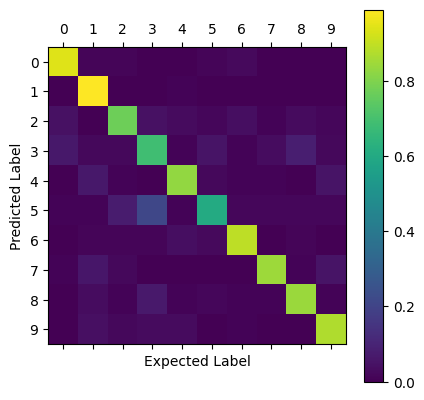

In [6]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, mode="TEST", rng=rng)

correct_predictions_count, confusion_matrix = run_reservoir(
    images_test,
    labels_test,
    normalized_reservoir,
    current_state,
    weight_input,
    weight_output,
    zeros_flush,
    bias_output=bias_output,
    mode="TEST",
    neuron_count=NEURON_COUNT,
    k=K,
    beta=BETA,
    tau=TAU,
    time_resolution=TIME_RESOLUTION,
    final_cols=FINAL_COLS)

print(f"""-------------------------
VARIABLES:
      
Beta = {BETA}
Tau = {TAU}
K = {K}

Neuron count = {NEURON_COUNT}

Flush time = {FLUSH_TIME}

Train batch size = {TRAIN_BATCH_SIZE}
Test batch size = {TEST_BATCH_SIZE}

Image threshold = {IMAGE_THRESHOLD}

Time to train = {time_to_train:.2f}s

-------------------------
ACCURACY:
""")
print(f"{correct_predictions_count} / {len(labels_test)} : {100*(correct_predictions_count/len(labels_test)):.2f} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xlabel("Expected Label")
plt.ylabel("Predicted Label")
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()